In [545]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns


In [546]:
FIRST_VERSION_DATA_PATH = "plain_data/first_version_table.csv"
FIRST_VERSION_LOG_PATH = "plain_data/first_version_logtable.csv"
UPDATED_DATA_PATH = "plain_data/updated_table.csv"
UPDATED_LOG_PATH = "plain_data/updated_logtable.csv"
REAL_PREDICTION_DATA_PATH = "plain_data/real_prediction_table.csv"
REAL_PREDICTION_LOG_PATH = "plain_data/real_prediction_logtable.csv"

SENSITIVITY_STUDY_DATA_PATH = "plain_data/sensitivity_study_table.csv"
SENSITIVITY_STUDY_LOG_PATH = "plain_data/sensitivity_study_logtable.csv"

SUCCISSIVE_HALVING_DATA_PATH = "plain_data/successive_halving_table.csv"
SUCCISSIVE_HALVING_LOG_PATH = "plain_data/successive_halving_logtable.csv"


# Get Data

In [547]:
update_data = False

In [548]:
def get_data(table_name:str, update_data) -> [pd.DataFrame, pd.DataFrame]:
    if update_data:
        experimenter = PyExperimenter(experiment_configuration_file_path="conf/experiment_config.yml",
                                database_credential_file_path="conf/database_credentials.yml",
                                table_name=table_name)
        main_table = experimenter.get_table()
        log_table = experimenter.get_logtable("sh_iterations")

        main_table.to_csv(f"plain_data/{table_name}_table.csv", index=False)
        log_table.to_csv(f"plain_data/{table_name}_logtable.csv", index=False)
    else:
        main_table = pd.read_csv(f"plain_data/{table_name}_table.csv")
        log_table = pd.read_csv(f"plain_data/{table_name}_logtable.csv")

    return main_table, log_table


In [549]:
# Not reproducible tables
first_version_table, first_version_logtable = get_data("priorbai_experiments", update_data)
kernel_table, kernel_logtable = get_data("priorbai_experiments_lcbench_kernels", update_data)
real_prediction_table, real_prediction_logtable = get_data("priorbai_experiments_lcbench_kernels_ys", update_data)


# reproducible table
sensitivity_study_table, sensitivity_study_logtable = get_data("sensitivity_study", update_data)
successive_halving_table, successive_halving_logtable = get_data("successive_halving", update_data)


# Display Head of Main Data

In [550]:
first_version_table.head()

,ID,run_id,num_arms,benchmark,seed,prior,performance_prior_std,sigma0,epsilon,delta,...,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,arm_id_selected,regret,epsilon_optimal,best_arm,end_date,error
0,1,__AUTO__,32,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,32.0,96.0,1.0,1.0,0.0,0.00000,1.0,1.0,2026-01-24 08:41:01,NaN
1,2,__AUTO__,64,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,64.0,224.0,1.0,2.0,0.0,0.00000,1.0,1.0,2026-01-24 08:33:37,NaN
2,3,__AUTO__,128,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,128.0,512.0,1.0,2.0,0.0,0.00000,1.0,1.0,2026-01-24 08:41:00,NaN
3,4,__AUTO__,256,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,256.0,1152.0,1.0,2.0,0.0,0.00000,1.0,1.0,2026-01-24 08:25:16,NaN
4,5,__AUTO__,32,lcbench,0,uniform,0.01,0.01,0.01,0.05,...,52.0,96.0,1.0,3.0,16.0,0.10709,0.0,0.0,2026-01-24 08:37:24,NaN


In [551]:
first_version_logtable.sort_values("experiment_id").head()

,ID,experiment_id,timestamp,iteration,num_arms,best_arm_included,budget_spent_so_far,N_stop
54020,54021,1,2026-01-24 08:41:00,4,2,1,96.0,3.026242e+06
54007,54008,1,2026-01-24 08:40:59,2,8,1,64.0,1.281531e+07
54016,54017,1,2026-01-24 08:41:00,3,4,1,80.0,6.407575e+06
53932,53933,1,2026-01-24 08:40:59,0,32,1,32.0,5.131354e+07
53946,53947,1,2026-01-24 08:40:59,1,16,1,48.0,2.563061e+07


# Merge DataFrames

In [552]:
def merge_dataframes(main_df: pd.DataFrame, log_df: pd.DataFrame, ) -> pd.DataFrame:
    log_df = log_df.drop(columns=["ID"], errors='ignore')
    return main_df.merge(log_df, left_on="ID", right_on="experiment_id", how="left", suffixes=('_final', '_logtable'))

def subselect_max_budget_entries(merged_df: pd.DataFrame, num_arms:int) -> pd.DataFrame:
    idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']
    merged_df = merged_df[idx]
    merged_df = merged_df[merged_df["num_arms_final"] == num_arms]
    return merged_df

merged_first_version = merge_dataframes(first_version_table, first_version_logtable)
merged_kernel = merge_dataframes(kernel_table, kernel_logtable)
merged_real_prediction = merge_dataframes(real_prediction_table, real_prediction_logtable)
merged_sensitivity_study = merge_dataframes(sensitivity_study_table, sensitivity_study_logtable)
merged_successive_halving = merge_dataframes(successive_halving_table, successive_halving_logtable)

merged_first_version = subselect_max_budget_entries(merged_first_version, 256)
merged_kernel = subselect_max_budget_entries(merged_kernel, 256)
merged_real_prediction = subselect_max_budget_entries(merged_real_prediction, 256)
merged_sensitivity_study = subselect_max_budget_entries(merged_sensitivity_study, 256)
merged_successive_halving = subselect_max_budget_entries(merged_successive_halving, 256)

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/4050960953.py:6: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']


In [553]:
merged_real_prediction.sort_values("ID")

,ID,run_id,num_arms_final,benchmark,kernel,seed,prior,performance_prior_std,sigma0,epsilon,...,best_arm,end_date,error,experiment_id,timestamp,iteration,num_arms_logtable,best_arm_included,budget_spent_so_far,N_stop
24,4,__AUTO__,256,lcbench,rbf,0,uniform,0.01,0.0100,0.01,...,0.0,2026-01-24 11:35:45,NaN,4.0,2026-01-24 11:35:43,6.0,4.0,1.0,1024.0,874.248758
49,8,__AUTO__,256,lcbench,matern32,0,uniform,0.01,0.0100,0.01,...,0.0,2026-01-24 12:07:46,NaN,8.0,2026-01-24 12:07:45,6.0,4.0,1.0,1024.0,530.605250
74,12,__AUTO__,256,lcbench,matern52,0,uniform,0.01,0.0100,0.01,...,0.0,2026-01-24 11:46:30,NaN,12.0,2026-01-24 11:46:29,6.0,4.0,1.0,1024.0,576.565854
100,16,__AUTO__,256,lcbench,linear,0,uniform,0.01,0.0100,0.01,...,0.0,2026-01-24 11:40:18,NaN,16.0,2026-01-24 11:40:18,7.0,2.0,1.0,1152.0,564.752136
126,20,__AUTO__,256,lcbench,rbf,1,uniform,0.01,0.0100,0.01,...,0.0,2026-01-24 11:38:54,NaN,20.0,2026-01-24 11:38:54,7.0,2.0,0.0,1152.0,313.225887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139557,23984,__AUTO__,256,lcbench,linear,98,indicator,0.01,0.0001,0.01,...,0.0,2026-01-24 11:32:36,NaN,23984.0,2026-01-24 11:32:36,6.0,4.0,0.0,1024.0,231.483653
139583,23988,__AUTO__,256,lcbench,rbf,99,indicator,0.01,0.0001,0.01,...,0.0,2026-01-24 12:02:33,NaN,23988.0,2026-01-24 12:02:33,7.0,2.0,0.0,1152.0,743.676132
139608,23992,__AUTO__,256,lcbench,matern32,99,indicator,0.01,0.0001,0.01,...,0.0,2026-01-24 11:46:18,NaN,23992.0,2026-01-24 11:46:17,6.0,4.0,0.0,1024.0,0.000000
139633,23996,__AUTO__,256,lcbench,matern52,99,indicator,0.01,0.0001,0.01,...,1.0,2026-01-24 11:39:34,NaN,23996.0,2026-01-24 11:39:34,6.0,4.0,1.0,1024.0,0.000000


# Evaluate How often we stop early

In [554]:
def create_table_summary(merged_df: pd.DataFrame) -> pd.DataFrame:
    return merged_df.groupby("prior").agg(
        avg_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="mean"),
        std_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="std"),
        avg_regret=pd.NamedAgg(column="regret", aggfunc="mean"),
        std_regret=pd.NamedAgg(column="regret", aggfunc="std"),
    ).reset_index()

In [555]:
synthethic_first_table_overview = create_table_summary(merged_first_version[merged_first_version["benchmark"] == "synthetic"])
lcbench_first_table_overview = create_table_summary(merged_first_version[merged_first_version["benchmark"] == "lcbench"])
lcbench_kernel_table_overview = create_table_summary(merged_kernel)
lcbench_real_prediction_table_overview = create_table_summary(merged_real_prediction)
lcbench_sensitivity_study_table_overview = create_table_summary(merged_sensitivity_study)

In [556]:
synthethic_first_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,1061.973333,269.208078,0.0,0.0
1,inverse_rank,1152.000000,0.000000,0.0,0.0
2,performance,933.546667,360.079898,0.0,0.0
3,rank,256.000000,0.000000,0.0,0.0
4,uniform,1152.000000,0.000000,0.0,0.0


In [557]:
lcbench_first_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,1058.560000,162.032099,0.052179,0.057252
1,inverse_rank,1122.133333,89.952992,0.055419,0.061510
2,performance,968.106667,204.580038,0.054312,0.056018
3,rank,910.933333,229.942516,0.051001,0.054482
4,uniform,1101.653333,62.631159,0.053712,0.056223


In [558]:
lcbench_kernel_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,1035.733333,128.048920,0.102426,0.096765
1,inverse_rank,1111.573333,101.592087,0.109247,0.105035
2,performance,955.249374,181.701723,0.097928,0.093879
3,rank,925.333333,206.809794,0.098805,0.095290
4,uniform,1066.133333,66.433576,0.101277,0.094304


In [559]:
lcbench_real_prediction_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,1049.407840,159.352591,0.022360,0.039541
1,inverse_rank,1088.213333,144.308658,0.037775,0.065623
2,performance,994.773333,195.585071,0.023661,0.039341
3,rank,906.560000,217.905060,0.022314,0.039520
4,uniform,1098.453333,66.332454,0.022085,0.039005


In [560]:
lcbench_sensitivity_study_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,1015.76,111.334961,0.032118,0.046157
1,inverse_rank,1101.12,76.616428,0.035498,0.048979
2,performance,889.80,221.037394,0.031936,0.046014
3,rank,812.56,239.459181,0.031216,0.045894
4,uniform,1043.00,45.510611,0.032566,0.046427


# Plot Perofmrance and consumed budget

In [561]:
def plot_performance_and_budget(merged_df: pd.DataFrame, benchmark_name: str, fig_title: str, hue:str = None):
    def create_boxplot(x,y,ax):
        if hue is not None:
            sns.boxplot(data=merged_df[merged_df["benchmark"] == benchmark_name], x=x, y=y, hue=hue, ax=ax)
        else:
            sns.boxplot(data=merged_df[merged_df["benchmark"] == benchmark_name], x=x, y=y, ax=ax)
    
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # Create boxplot for regret
    create_boxplot("prior", "regret", ax[0])
    ax[0].set_title(f"Regret Distribution for {benchmark_name}")
    ax[0].set_ylabel("Regret")
    ax[0].set_xlabel("Prior")

    # Create boxplot for consumed budget
    create_boxplot("prior", "consumed_budget", ax[1])
    ax[1].set_title(f"Consumed Budget Distribution for {benchmark_name}")
    ax[1].set_ylabel("Consumed Budget")
    ax[1].set_xlabel("Prior")

    # Plot budget_spent_so_far
    create_boxplot("prior", "iteration", ax[2])
    ax[2].set_title(f"Max Fidelity Level Reached for {benchmark_name}")
    ax[2].set_ylabel("Max fidelity level reached")
    ax[2].set_xlabel("Prior")

    fig.suptitle(fig_title)
    fig.tight_layout()
    fig.show()

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/105537552.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


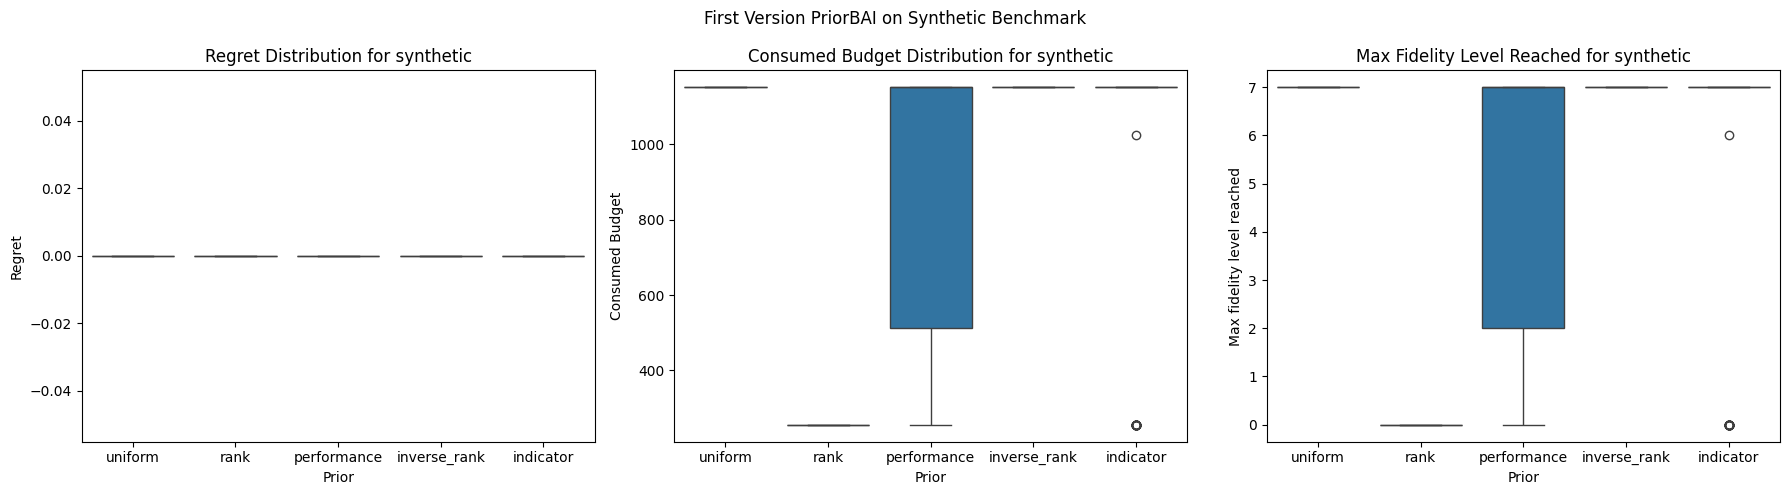

In [562]:
plot_performance_and_budget(merged_first_version, "synthetic", "First Version PriorBAI on Synthetic Benchmark", hue=None)

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/105537552.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


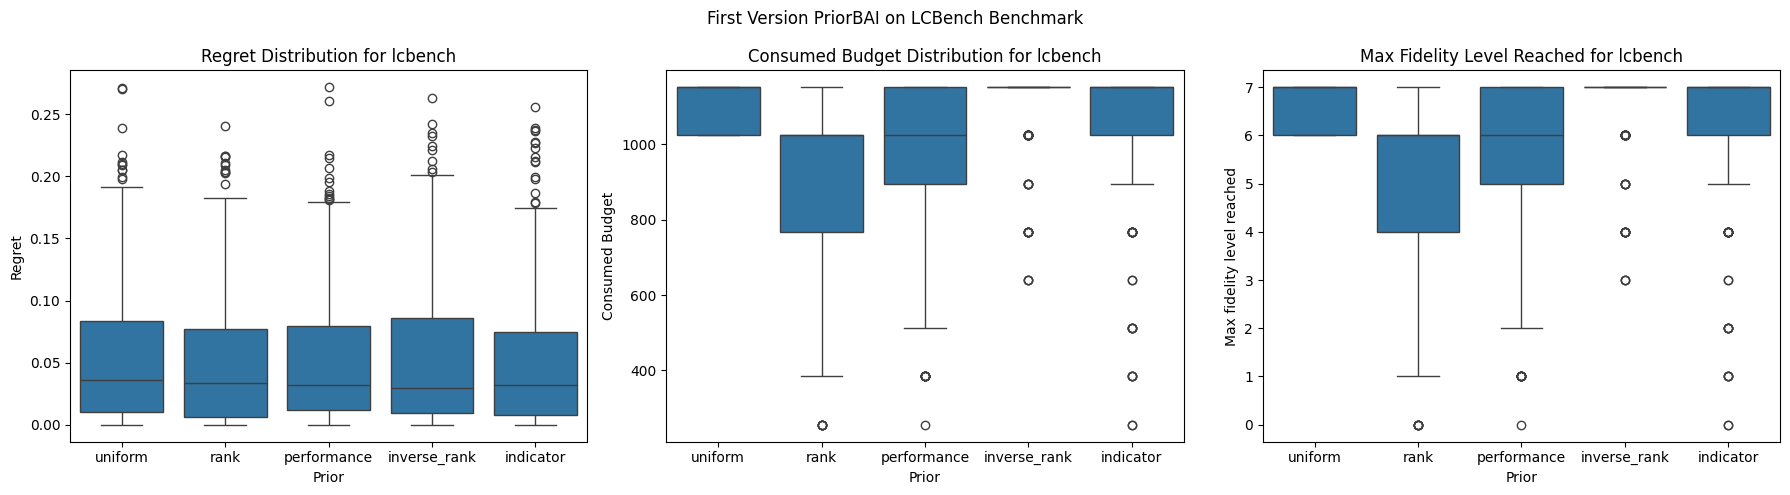

In [563]:
plot_performance_and_budget(merged_first_version, "lcbench", "First Version PriorBAI on LCBench Benchmark", hue=None)

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/105537552.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


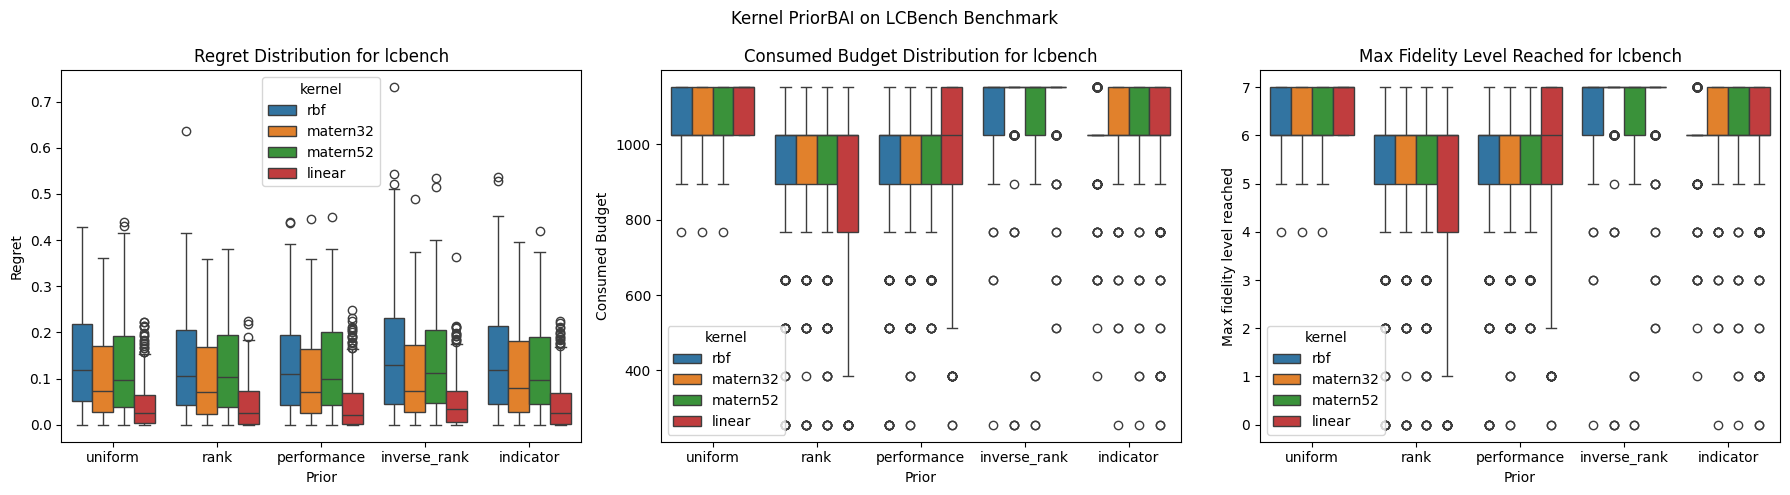

In [564]:
plot_performance_and_budget(merged_kernel, "lcbench", "Kernel PriorBAI on LCBench Benchmark", hue="kernel")

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/105537552.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


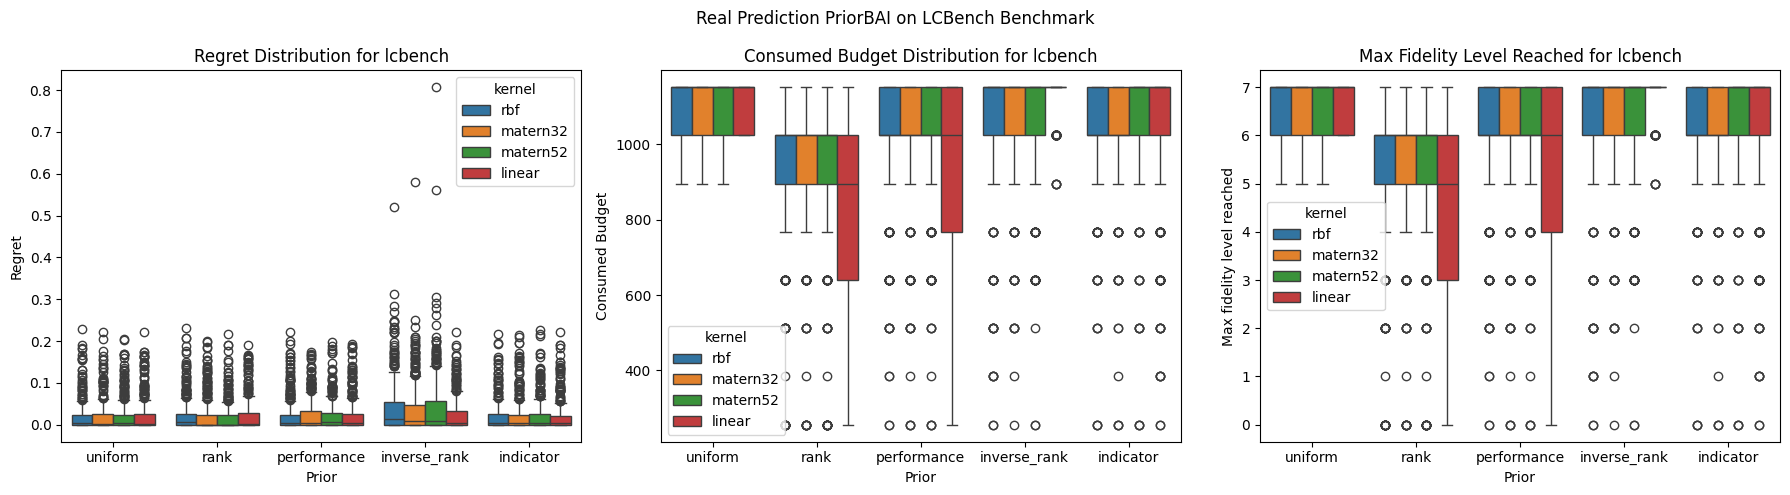

In [565]:
plot_performance_and_budget(merged_real_prediction, "lcbench", "Real Prediction PriorBAI on LCBench Benchmark", hue="kernel")

# Ablation Plots
GIST: Echte performance besser als predicted performance.
Hyperparmater haben impact, aber mit linear kernel und rank prior haben wir einen sehr konsistent speedup.

In [566]:
real_performance_sensitivity = merged_sensitivity_study[merged_sensitivity_study["use_predicted_y"] == False]
predicted_performance_sensitivity = merged_sensitivity_study[merged_sensitivity_study["use_predicted_y"] == True]

In [567]:
create_table_summary(real_performance_sensitivity)

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,1019.360000,115.385112,0.022768,0.038884
1,inverse_rank,1100.266667,72.836397,0.024260,0.039148
2,performance,878.053333,234.918712,0.023442,0.039570
3,rank,780.106667,245.384813,0.022516,0.038975
4,uniform,1046.640000,48.845137,0.022718,0.038881


In [568]:
create_table_summary(predicted_performance_sensitivity)

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,1012.160000,107.022804,0.041467,0.050741
1,inverse_rank,1101.973333,80.217080,0.046735,0.054892
2,performance,901.546667,205.578239,0.040430,0.050248
3,rank,845.013333,228.850965,0.039915,0.050423
4,uniform,1039.360000,41.599410,0.042415,0.051046


In [576]:
def sensitivity_plots(merged_df: pd.DataFrame, merged_successive_halving: pd.DataFrame, benchmark_name: str, fig_title: str, sigmas:list[float], hue:str = None):
    def create_boxplot(sigma_data,x,y,ax):
        # Set more obvious colors in the plot
        if hue is not None:
            sns.boxplot(data=sigma_data, x=x, y=y, hue=hue, ax=ax, palette="Set2")
        else:
            sns.boxplot(data=sigma_data, x=x, y=y, ax=ax, palette="Set2")

    fig, ax = plt.subplots(3, 3, figsize=(18, 18))
    mean_merged_successive_halving_regret = merged_successive_halving["regret"].mean()
    std_merged_successive_halving_regret = merged_successive_halving["regret"].std()
    mean_merged_successive_halving_consumed_budget = merged_successive_halving["consumed_budget"].mean()
    std_merged_successive_halving_consumed_budget = merged_successive_halving["consumed_budget"].std()
    print(f"Successive Halving Mean Regret: {mean_merged_successive_halving_regret}, Std Dev: {std_merged_successive_halving_regret}")
    print(f"Successive Halving Mean Consumed Budget: {mean_merged_successive_halving_consumed_budget}, Std Dev: {std_merged_successive_halving_consumed_budget}")

    for plot_number, sigma in enumerate(sigmas):
        sigma_data = merged_df[merged_df["sigma0"] == sigma]
        create_boxplot(sigma_data, "prior", "regret", ax[plot_number, 0])
        ax[plot_number, 0].set_title(f"Regret Distribution for {benchmark_name}")
        ax[plot_number, 0].set_ylabel("Regret")
        ax[plot_number, 0].set_xlabel("Prior")
        ax[plot_number, 0].set_ylim(0, 0.3)
        ax[plot_number, 0].axhline(y=mean_merged_successive_halving_regret, color='r', linestyle='-', label='Successive Halving Mean Regret')
        # add shaded area for std dev
        ax[plot_number, 0].axhline(y=mean_merged_successive_halving_regret + std_merged_successive_halving_regret, color='r', linestyle=':', label='Successive Halving +1 Std Dev')
        ax[plot_number, 0].axhline(y=mean_merged_successive_halving_regret - std_merged_successive_halving_regret, color='r', linestyle=':', label='Successive Halving -1 Std Dev')

        # Create boxplot for consumed budget
        create_boxplot(sigma_data, "prior", "consumed_budget", ax[plot_number, 1])
        ax[plot_number, 1].set_title(f"Consumed Budget Distribution for {benchmark_name}")
        ax[plot_number, 1].set_ylabel("Consumed Budget")
        ax[plot_number, 1].set_xlabel("Prior")
        ax[plot_number, 1].axhline(y=mean_merged_successive_halving_consumed_budget, color='r', linestyle='-', label='Successive Halving Mean Consumed Budget')
        ax[plot_number, 1].axhline(y=mean_merged_successive_halving_consumed_budget + std_merged_successive_halving_consumed_budget, color='r', linestyle=':', label='Successive Halving +1 Std Dev')
        ax[plot_number, 1].axhline(y=mean_merged_successive_halving_consumed_budget - std_merged_successive_halving_consumed_budget, color='r', linestyle=':', label='Successive Halving -1 Std Dev')
        
        # Plot budget_spent_so_far
        create_boxplot(sigma_data, "prior", "iteration", ax[plot_number, 2])
        ax[plot_number, 2].set_title(f"Max Fidelity Level Reached for {benchmark_name}")
        ax[plot_number, 2].set_ylabel("Max fidelity level reached")
        ax[plot_number, 2].set_xlabel("Prior")

        fig.suptitle(fig_title)
        fig.tight_layout()
        fig.show()

## Sensitivity, with varying delta
### Predicted Performance

Successive Halving Mean Regret: 0.022693028068542453, Std Dev: 0.039084108962017146
Successive Halving Mean Consumed Budget: 1152.0, Std Dev: 0.0


/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


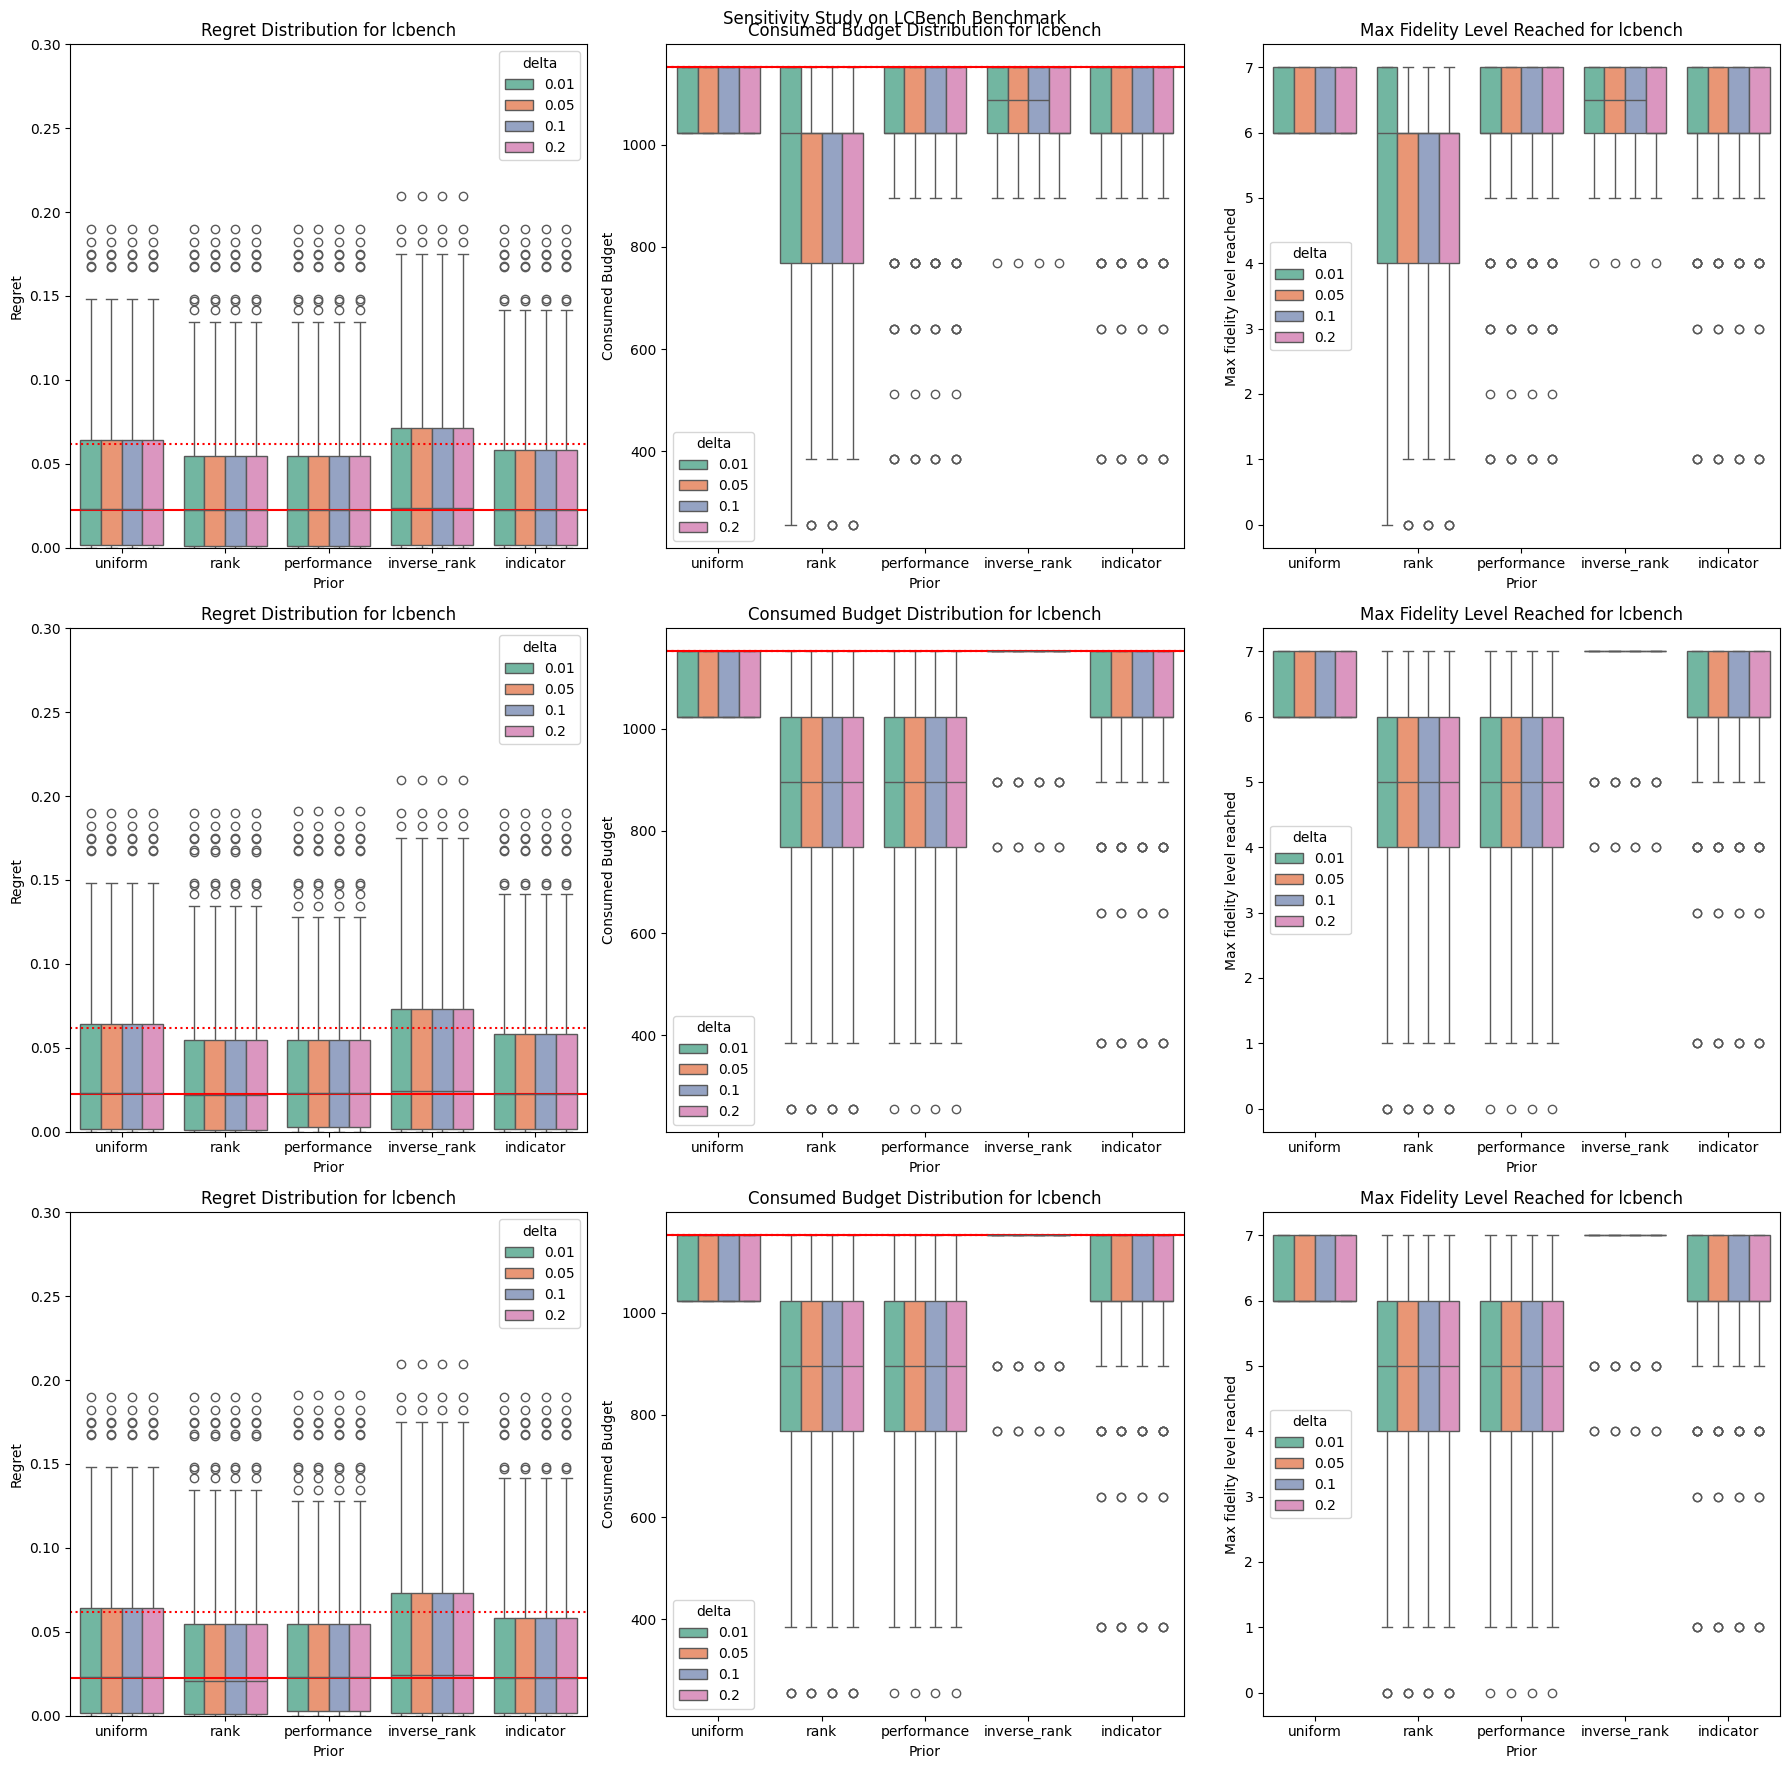

In [577]:
base_subset = predicted_performance_sensitivity[(predicted_performance_sensitivity["epsilon"] == 0.01)]
sensitivity_plots(base_subset, merged_successive_halving, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="delta")

### Real Performance

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


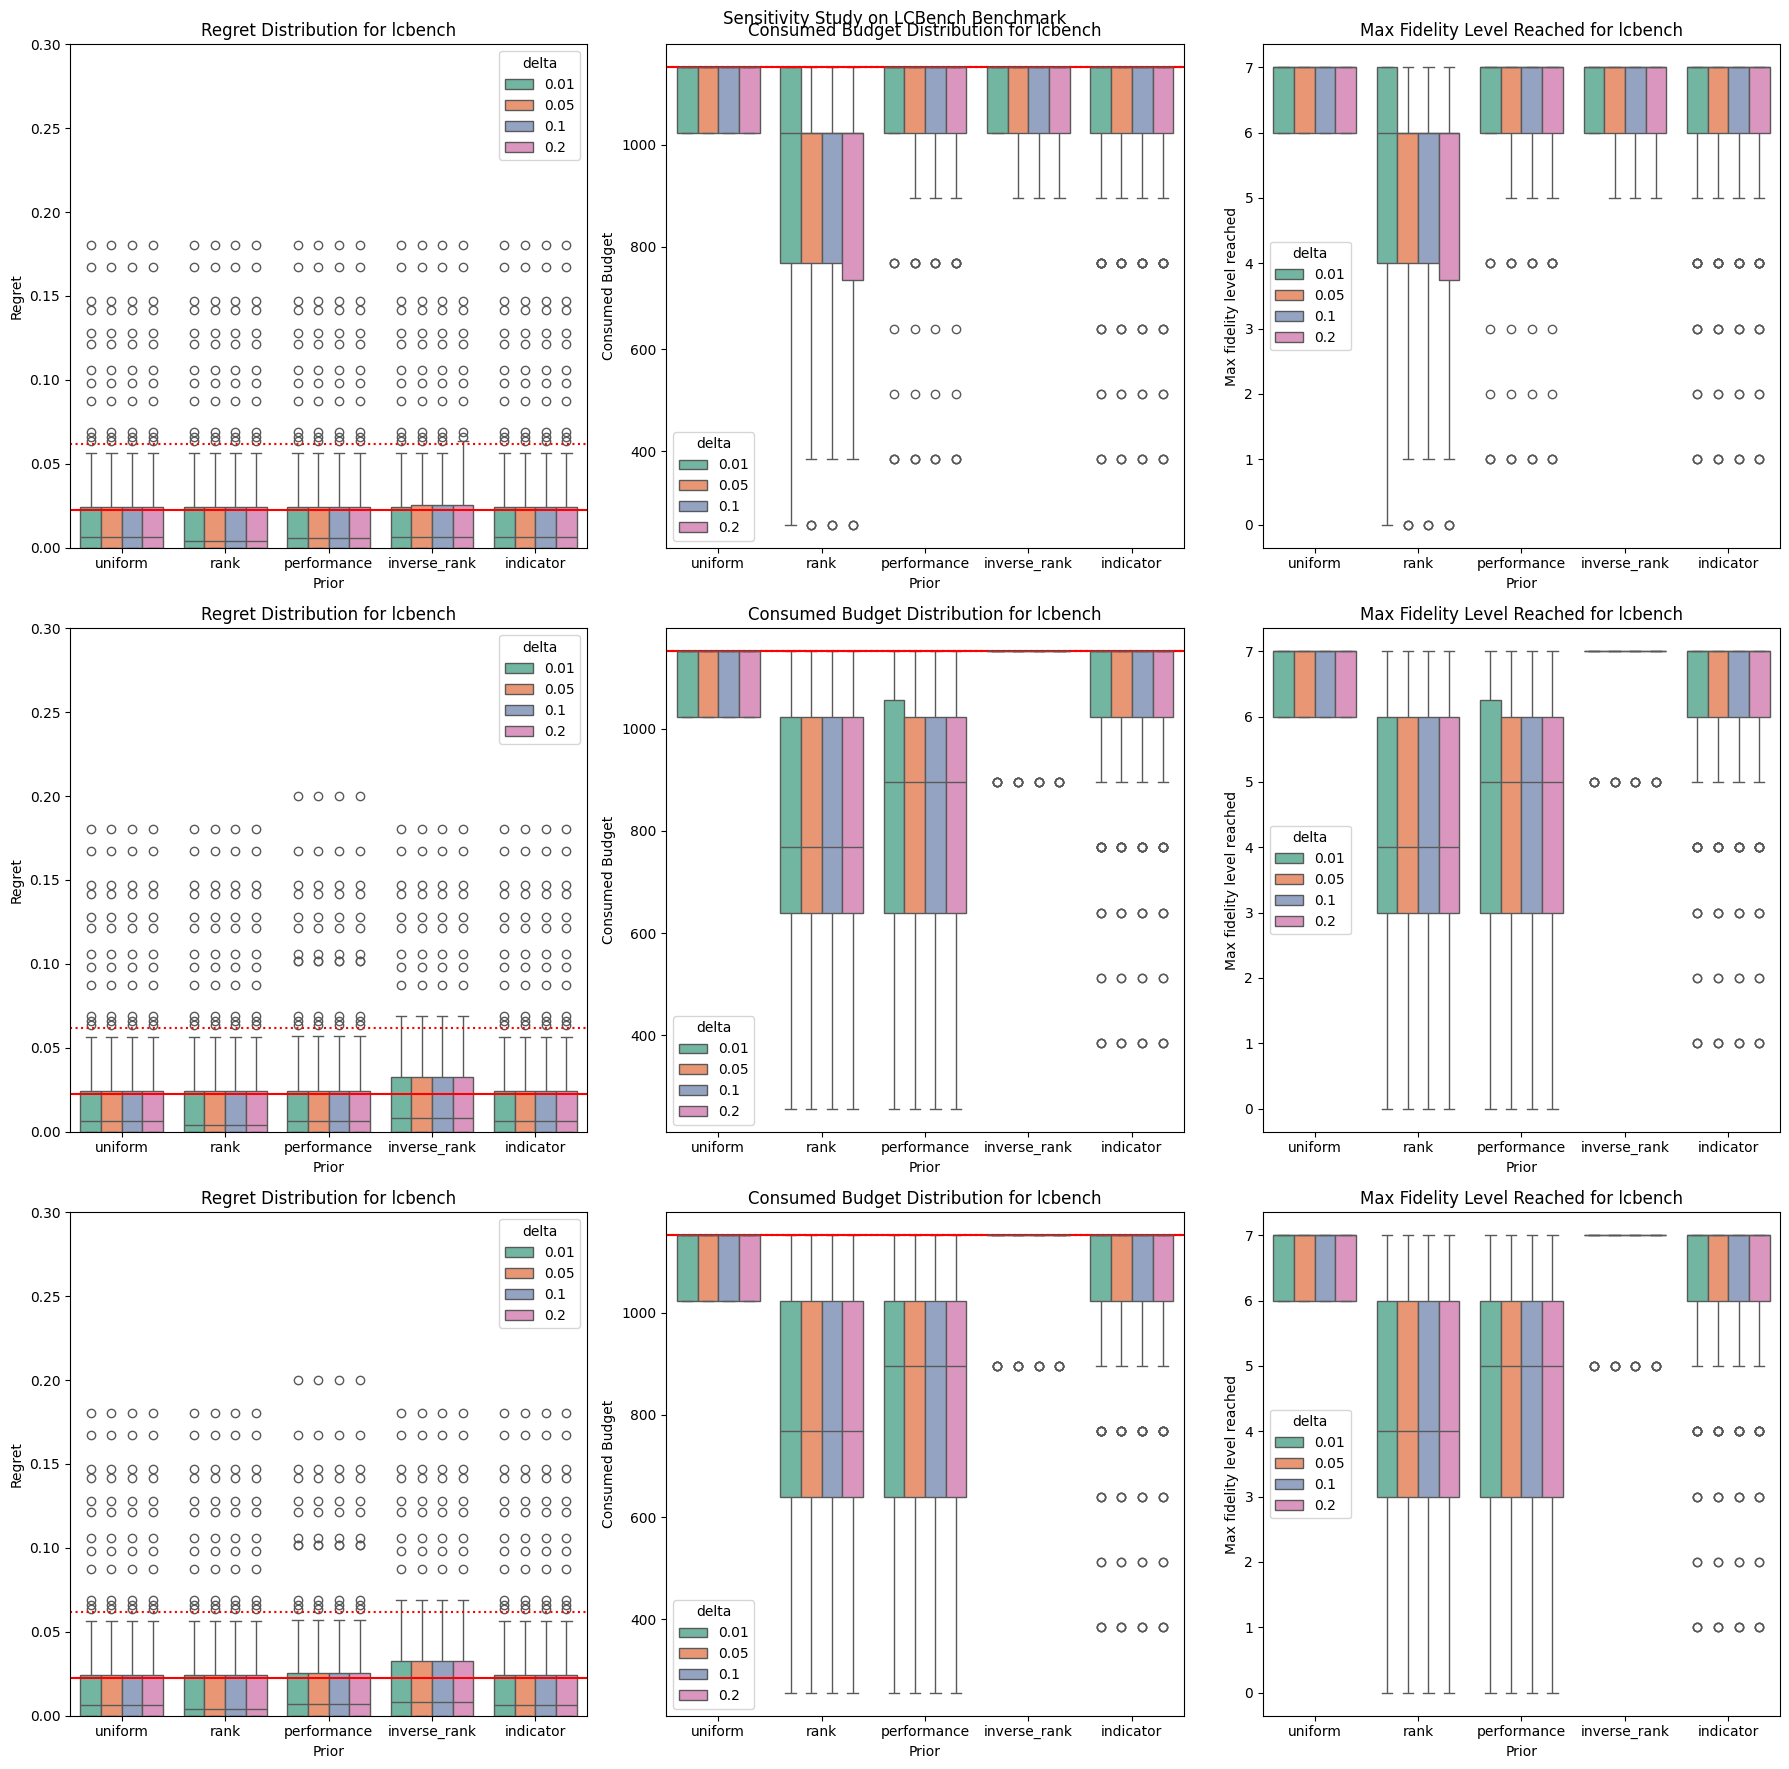

In [571]:
base_subset = real_performance_sensitivity[(real_performance_sensitivity["epsilon"] == 0.01)]
sensitivity_plots(base_subset, merged_successive_halving, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="delta")

## Predicted Performance Sensitivity, with varying epsilon
### Predicted Performance

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


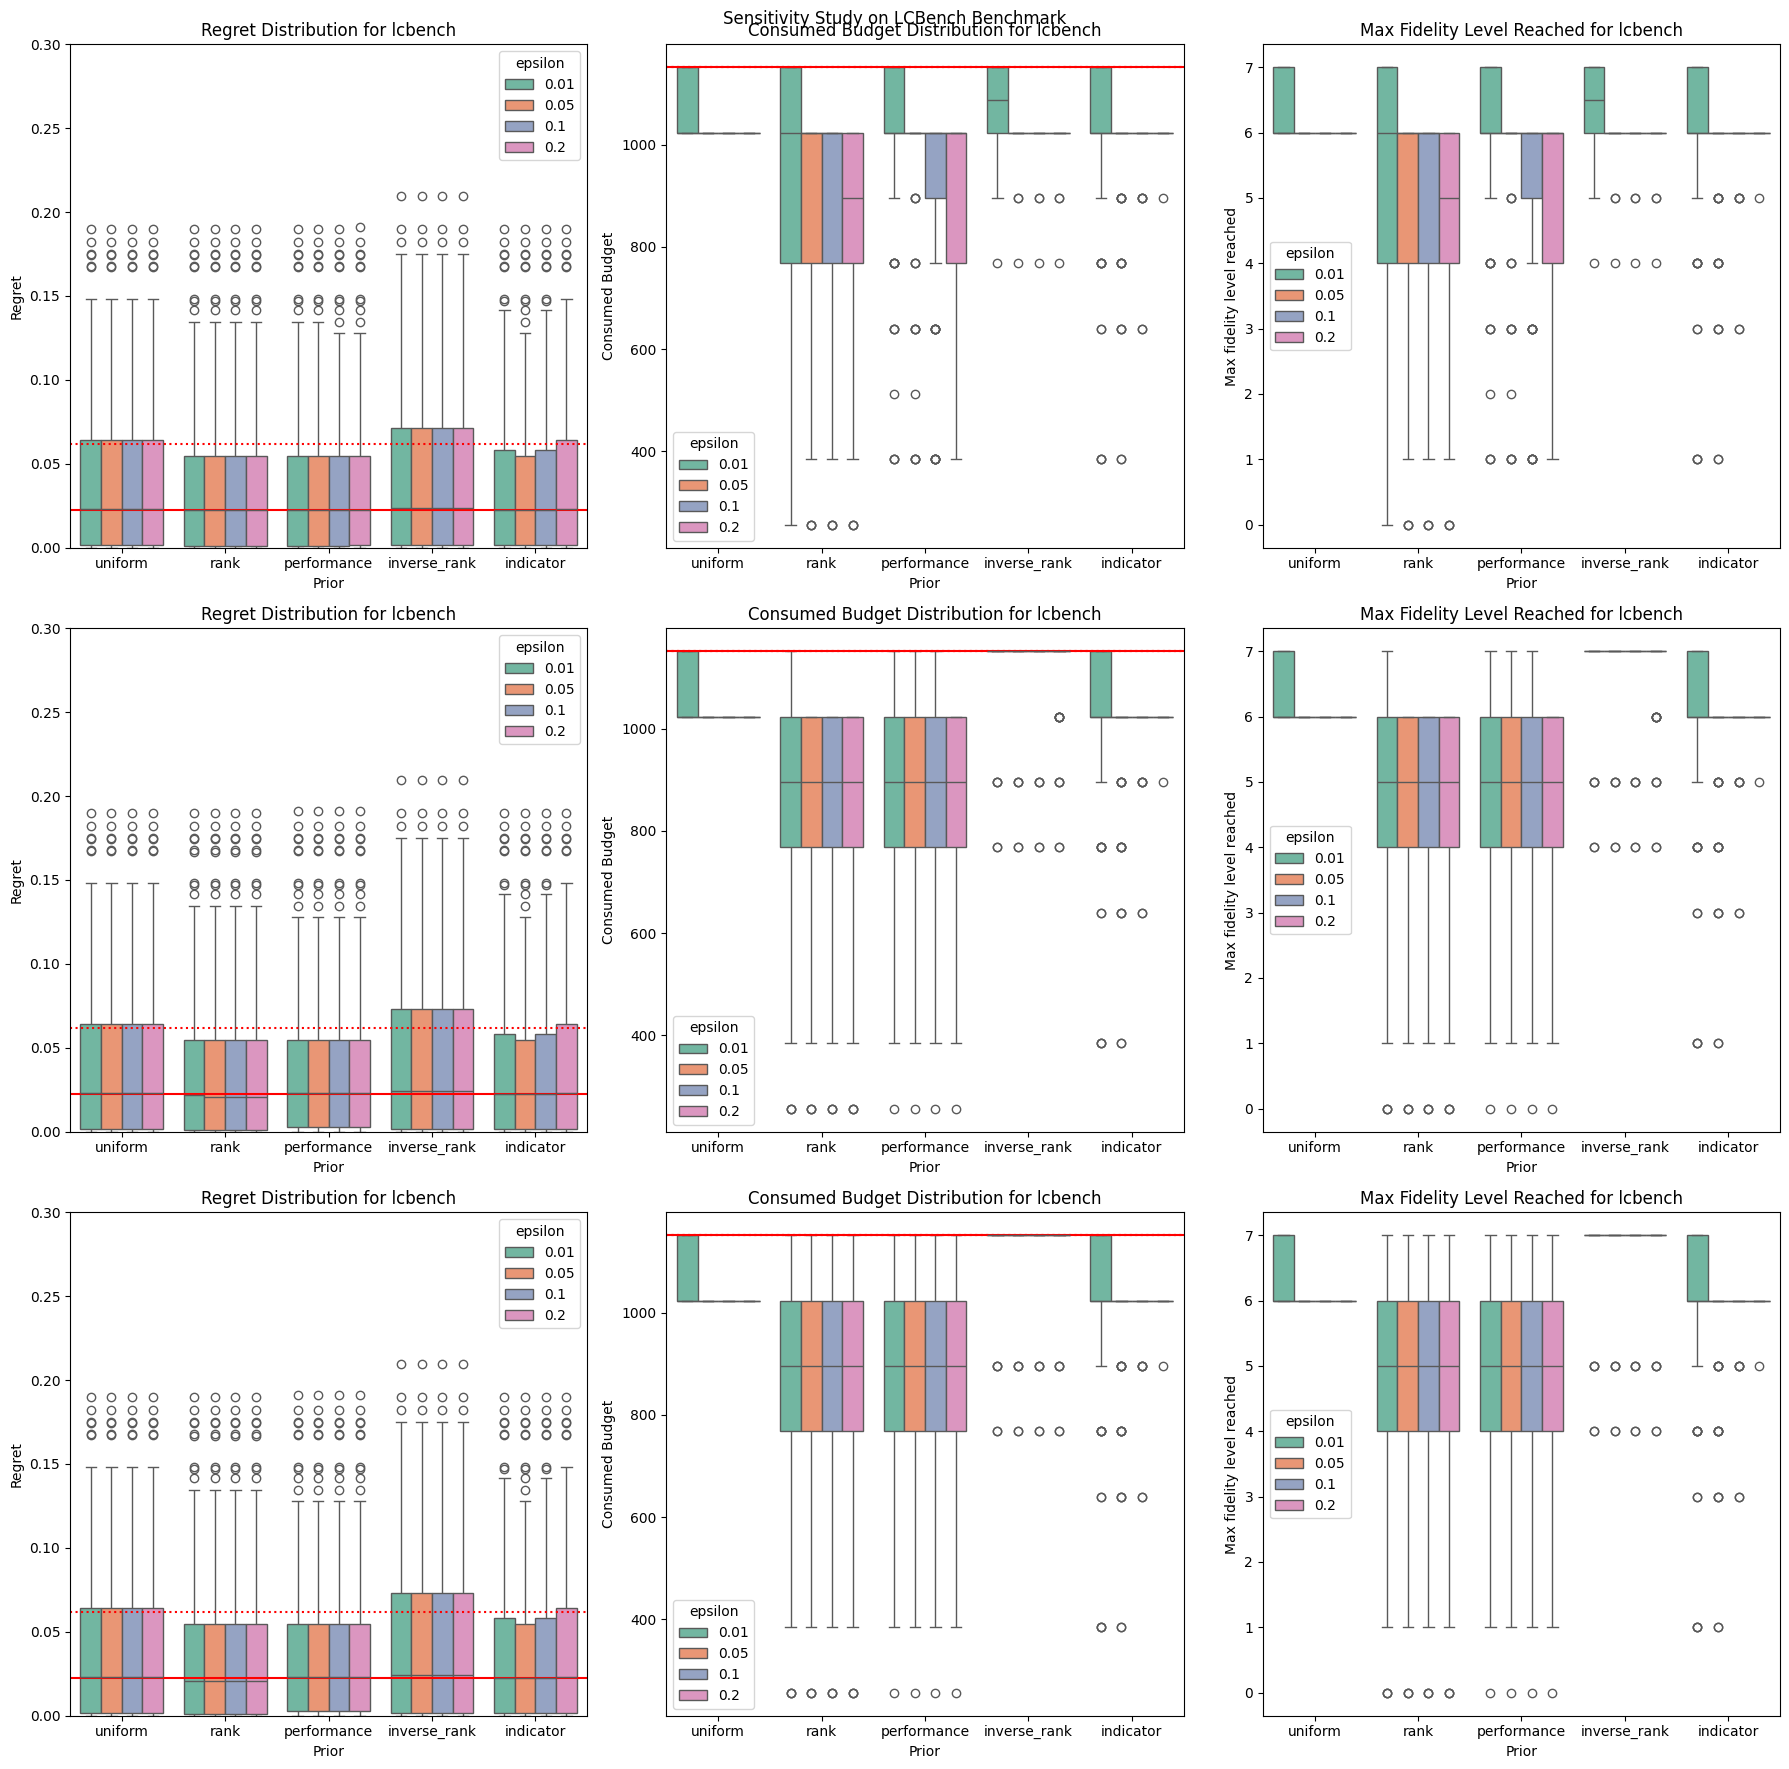

In [572]:
base_subset = predicted_performance_sensitivity[(predicted_performance_sensitivity["delta"] == 0.01)]
sensitivity_plots(base_subset, merged_successive_halving,"lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="epsilon")

### Real Performance

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_3643/2113392245.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


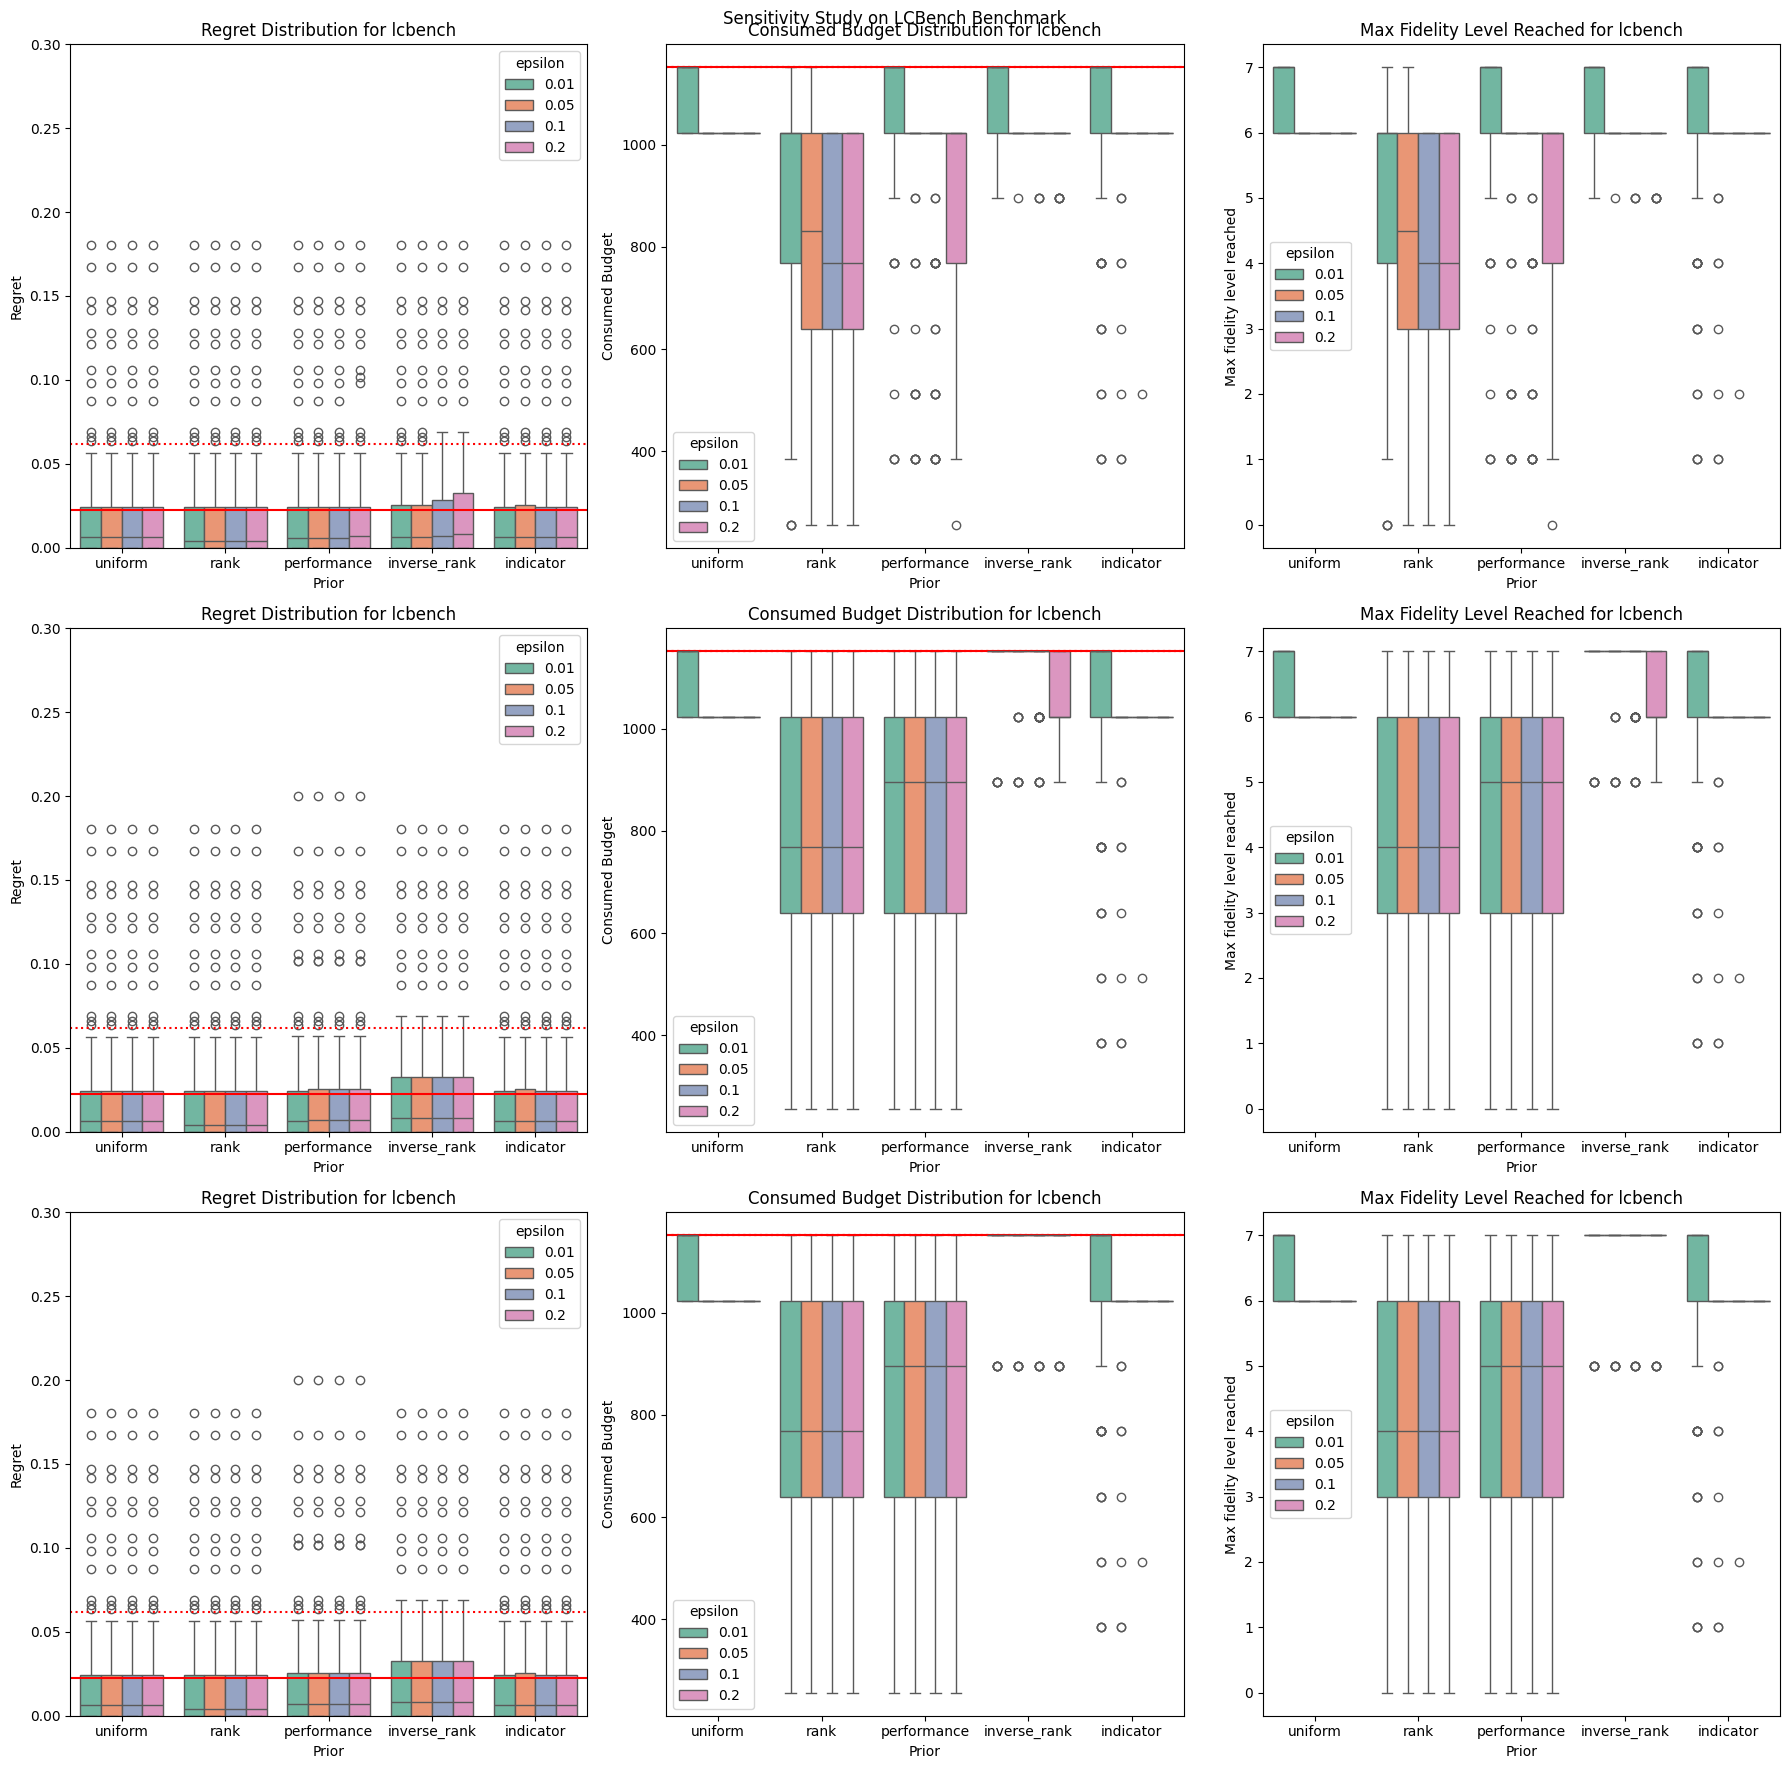

In [573]:
base_subset = real_performance_sensitivity[(real_performance_sensitivity["delta"] == 0.1)]
sensitivity_plots(base_subset, merged_successive_halving, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="epsilon")